# Support Vector Machines

## Concepts Learned

1. Support Vector Machines.
    * Use distances between data points to create boundary. Uses the boundary for classification.
    * Polynomial Kernal - Add more dimensions to the dataset, making it easier to fit and more accurate. Amount dims added is determined by the value of "d" inputed
    * Radial Basis Function (RBF) Kernal - It just the Polynomial Kernal but opperates in infinite diminesons. Long Story short, the RBF uses a function that contains e^ab, to determine similarity between 2 points. e^ab can be broken down into a inifnite taylor series, meaning that forumal gives us similiarity between two point from a infintie dimesional pov.

🚩
Deliverable: Train an SVC with an RBF kernel. Use GridSearchCV over a 4×4 grid of C and γ values and plot the resulting validation score heatmap.

In [28]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
df = pd.read_csv("ccf.csv")
df.head(), len(df)

(     Time        V1        V2        V3        V4        V5   Amount  Class
 0  121958 -2.289061 -1.313758 -0.452562 -0.392802  0.224787  1600.89      0
 1  146867  1.432482 -1.095302 -0.129910 -1.362911 -1.017335  4191.85      0
 2  131932  1.214722 -0.168797  0.581433  0.699020  0.964415  3271.32      0
 3  103694 -0.880864  0.110956 -0.203236 -0.243510  0.362543  1377.51      0
 4  119879 -0.881879  0.786970  1.110118  0.015365 -1.135162  4838.72      0,
 1000)

In [30]:
df.drop(columns=["Time"], inplace=True)
X = df.drop(columns=['Class'])
y =df['Class']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)
len(X_train), len(X_test)

(800, 200)

In [32]:
scaleCol = ColumnTransformer([
    ("Numeric Scaling", StandardScaler(), X_train.columns)
])


pipeline  = Pipeline([
    ('Scaling', scaleCol),
    ("Model", SVC())
])


params = {
    "Model__C": [0.1, 1, 10,100],
    "Model__gamma": [0.1, 1, 10,100]
}

gs = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

In [33]:
gs.fit(X_train, y_train)
gs.best_score_

np.float64(0.98125)

In [34]:
gs.best_params_

{'Model__C': 0.1, 'Model__gamma': 0.1}

In [35]:
a,b,c = gs.cv_results_['param_Model__C'], gs.cv_results_['param_Model__gamma'], gs.cv_results_['mean_test_score']

<Axes: xlabel='Gamma', ylabel='C'>

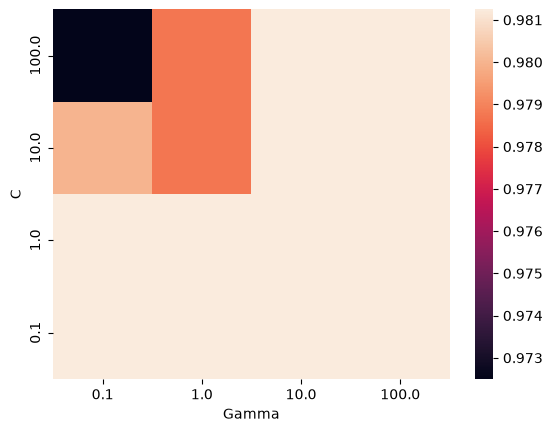

In [36]:
df = pd.DataFrame({"C": a, "Gamma": b, "value": c})  # a, b, c same length
heatmap_data = df.pivot(index="C", columns="Gamma", values="value").sort_index(ascending=False)
sns.heatmap(heatmap_data)

In [37]:
y_pred = gs.best_estimator_.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.985
